# **ε-greedy SARSA for Windy Gridworld**


### **Assignment 6 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

Finished at 8000 time steps, 177 episodes.
Wind per column: [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]


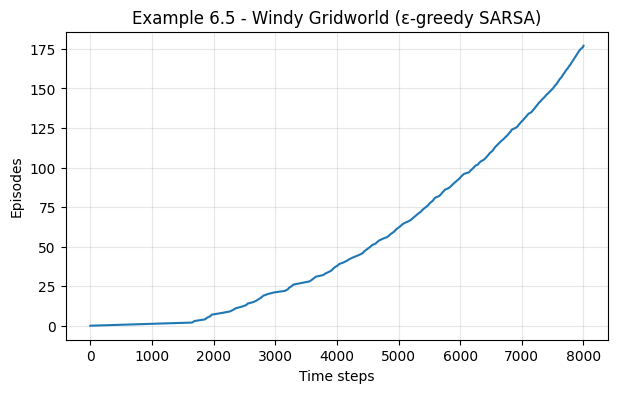

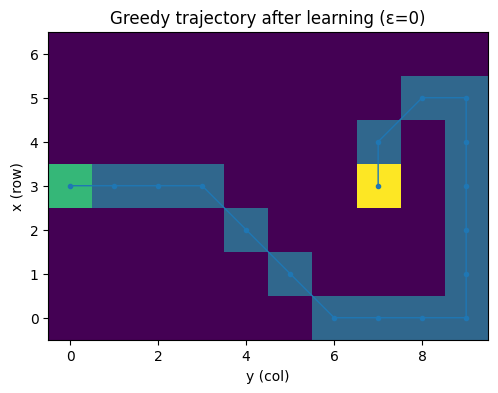

Greedy path length: 17 (reached goal)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Example 6.5 — Windy Gridworld (Sutton & Barto, 2nd ed.)
# SARSA with ε-greedy:
#   epsilon = 0.1, alpha = 0.5, gamma = 1.0, Q0 = 0
# Run until 8000 time steps, plot Episodes vs Time steps.
# Actions order: 0: Left, 1: Right, 2: Up, 3: Down
# State = (x=row, y=col)  where x is up-down, y is left-right
# ==========================================================

WORLD_HEIGHT = 7
WORLD_WIDTH  = 10

# wind strength per column (pushes up = decreases x)
WIND = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0], dtype=int)

# Actions: 0: Left, 1: Right, 2: Up, 3: Down
LEFT, RIGHT, UP, DOWN = 0, 1, 2, 3
ACTIONS = [LEFT, RIGHT, UP, DOWN]

EPSILON = 0.1
ALPHA   = 0.5
GAMMA   = 1.0
REWARD  = -1.0  # per step until goal

START = (3, 0)
GOAL  = (3, 7)

def step(state, action):
    """
    Deterministic Windy Gridworld transition
    """
    x, y = state
    w = WIND[y]  # wind from current column

    # apply action first
    if action == LEFT:
        x2, y2 = x, max(y - 1, 0)
    elif action == RIGHT:
        x2, y2 = x, min(y + 1, WORLD_WIDTH - 1)
    elif action == UP:
        x2, y2 = max(x - 1, 0), y
    elif action == DOWN:
        x2, y2 = min(x + 1, WORLD_HEIGHT - 1), y
    else:
        raise ValueError("Unknown action")

    # then apply wind upward (decrease row index)
    x2 = max(x2 - w, 0)

    return (x2, y2)

def epsilon_greedy(Q, state, rng, epsilon=EPSILON):
    """ε-greedy with random tie-breaking."""
    if rng.random() < epsilon:
        return int(rng.integers(0, len(ACTIONS)))
    qs = Q[state[0], state[1], :]
    best = np.flatnonzero(qs == np.max(qs))
    return int(rng.choice(best))

def sarsa_example_6_5(max_time_steps=8000, seed=0, max_episode_length=10_000, verbosity=1):
    rng = np.random.default_rng(seed)
    Q = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, len(ACTIONS)), dtype=float)

    time_steps = 0
    episodes = 0

    # plot data: Episodes vs cumulative Time steps
    x_steps = [0]
    y_eps   = [0]

    while time_steps < max_time_steps:
        state = START
        a_idx = epsilon_greedy(Q, state, rng, epsilon=EPSILON)

        ep_len = 0
        while state != GOAL and time_steps < max_time_steps and ep_len < max_episode_length:
            action = ACTIONS[a_idx]
            next_state = step(state, action)
            r = REWARD

            if next_state == GOAL:
                # terminal: no next action value
                td_target = r
                Q[state[0], state[1], a_idx] += ALPHA * (td_target - Q[state[0], state[1], a_idx])

                state = next_state
                time_steps += 1
                ep_len += 1
                break
            else:
                next_a_idx = epsilon_greedy(Q, next_state, rng, epsilon=EPSILON)

                td_target = r + GAMMA * Q[next_state[0], next_state[1], next_a_idx]
                Q[state[0], state[1], a_idx] += ALPHA * (td_target - Q[state[0], state[1], a_idx])

                state = next_state
                a_idx = next_a_idx
                time_steps += 1
                ep_len += 1

        episodes += 1
        x_steps.append(time_steps)
        y_eps.append(episodes)

    if verbosity >= 1:
        print(f"Finished at {time_steps} time steps, {episodes} episodes.")
        print("Wind per column:", WIND.tolist())

    return Q, np.array(x_steps), np.array(y_eps)

def greedy_trajectory(Q, seed=123, max_steps=200):
    """
    Evaluate learned greedy policy (ε=0).
    Uses a fixed Random Number Generator for tie-breaking.
    """
    rng = np.random.default_rng(seed)
    state = START
    path = [state]

    for _ in range(max_steps):
        if state == GOAL:
            break
        qs = Q[state[0], state[1], :]
        best = np.flatnonzero(qs == np.max(qs))
        a_idx = int(rng.choice(best))
        state = step(state, ACTIONS[a_idx])
        path.append(state)

    reached = (path[-1] == GOAL)
    return path, reached

def plot_learning_curve(x_steps, y_eps):
    plt.figure(figsize=(7, 4))
    plt.plot(x_steps, y_eps)
    plt.xlabel("Time steps")
    plt.ylabel("Episodes")
    plt.title("Example 6.5 - Windy Gridworld (ε-greedy SARSA)")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_greedy_path(path, reached):
    grid = np.zeros((WORLD_HEIGHT, WORLD_WIDTH), dtype=int)
    for (x, y) in path:
        grid[x, y] = 1
    grid[START[0], START[1]] = 2
    grid[GOAL[0], GOAL[1]] = 3

    plt.figure(figsize=(7, 4))
    plt.imshow(grid, interpolation="nearest")
    plt.gca().invert_yaxis()
    title = "Greedy trajectory after learning (ε=0)"
    if not reached:
        title += " - Did Not reach goal"
    plt.title(title)
    plt.xlabel("y (col)")
    plt.ylabel("x (row)")
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    plt.plot(xs, ys, marker="o", linewidth=1, markersize=3)
    plt.show()

Q, x_steps, y_eps = sarsa_example_6_5(max_time_steps=8000, seed=0, verbosity=1)
plot_learning_curve(x_steps, y_eps)

path, reached = greedy_trajectory(Q, seed=0, max_steps=500)
plot_greedy_path(path, reached)

print("Greedy path length:", len(path) - 1, "(reached goal)" if reached else "(Did Not reach goal)")
